# Backtest Output Analysis

This notebook compares the multi-horizon model against the zero-forecast baseline using the exported backtest CSV files.

It provides:
- robust data loading from the project structure,
- aligned model vs baseline metrics (`mse`, `mae`, `r2`),
- rolling performance plots,
- yearly aggregated performance diagnostics,
- horizon-coefficient profile analysis (`p_1` to `p_12`).


In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [5]:
RESULTS_SUBDIR = "output_1year"  # set to "output_data" to inspect alternate run artifacts
MODEL_FILE = "prediction_backtest_results.csv"
BASELINE_FILE = "prediction_0_backtest_results.csv"


def resolve_results_file(filename: str, results_subdir: str = RESULTS_SUBDIR) -> Path:
    """Resolve a result file regardless of whether the notebook is launched from repo root or subfolder."""
    roots = [Path("."), Path("hurst_volatility_multi_year"), Path("..")]
    tried = []

    for root in roots:
        candidate = (root / results_subdir / filename).resolve()
        tried.append(str(candidate))
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f"Could not find '{filename}'. Tried:\n- " + "\n- ".join(tried)
    )


model_path = resolve_results_file(MODEL_FILE)
baseline_path = resolve_results_file(BASELINE_FILE)

model = pd.read_csv(model_path)
baseline = pd.read_csv(baseline_path)

print(f"Model file:    {model_path}")
print(f"Baseline file: {baseline_path}")
print(f"Model shape:   {model.shape}")
print(f"Baseline shape:{baseline.shape}")


Model file:    /Users/gregoireszymanski/Documents/work/dev/git-hurst-estimation/hurst_inference/hurst_volatility_multi_year/output_1year/prediction_backtest_results.csv
Baseline file: /Users/gregoireszymanski/Documents/work/dev/git-hurst-estimation/hurst_inference/hurst_volatility_multi_year/output_1year/prediction_0_backtest_results.csv
Model shape:   (2169, 18)
Baseline shape:(2169, 7)


In [6]:
METRICS = ["mse", "r2"]
HORIZON_COLS = [col for col in model.columns if col.startswith("p_")]


def parse_testing_label_to_date(testing: pd.Series) -> pd.Series:
    parsed = testing.str.extract(r"(?P<year>\d{4})_day_(?P<day>\d{1,3})")
    if parsed.isna().any(axis=None):
        bad = testing[parsed.isna().any(axis=1)].head().to_list()
        raise ValueError(f"Unable to parse testing labels. Examples: {bad}")

    parsed = parsed.astype(int)

    # For each year, use the last available day index (YYYY_day_XXX) as the reference day count.
    ref_days = parsed.groupby("year")["day"].transform("max").astype(float)

    year_start = pd.to_datetime(parsed["year"].astype(str) + "-01-01")
    calendar_days = pd.to_datetime(parsed["year"].astype(str) + "-12-31").dt.dayofyear.astype(float)

    # Map day index to a position within the year using ref_days rather than 365/366 as denominator.
    denom = np.maximum(ref_days - 1.0, 1.0)
    day_fraction = (parsed["day"].astype(float) - 1.0) / denom

    return year_start + pd.to_timedelta(day_fraction * (calendar_days - 1.0), unit="D")


def prepare_result_frame(df: pd.DataFrame, tag: str) -> pd.DataFrame:
    out = df.copy()
    out["testing_date"] = parse_testing_label_to_date(out["testing"])
    out = out.sort_values("testing_date").reset_index(drop=True)

    keep = ["testing", "testing_date", *METRICS, *HORIZON_COLS]
    keep = [c for c in keep if c in out.columns]
    out = out[keep]

    rename = {c: f"{c}_{tag}" for c in out.columns if c not in {"testing", "testing_date"}}
    return out.rename(columns=rename)


model_prepared = prepare_result_frame(model, "model")
baseline_prepared = prepare_result_frame(baseline, "baseline")

merged = model_prepared.merge(
    baseline_prepared,
    on=["testing", "testing_date"],
    how="inner",
    validate="one_to_one",
)

if len(merged) != len(model_prepared) or len(merged) != len(baseline_prepared):
    print(
        "Warning: merge dropped rows "
        f"(model={len(model_prepared)}, baseline={len(baseline_prepared)}, merged={len(merged)})."
    )

for metric in ["mse"]:
    merged[f"{metric}_improvement"] = merged[f"{metric}_baseline"] - merged[f"{metric}_model"]
    merged[f"{metric}_improvement_pct"] = np.where(
        merged[f"{metric}_baseline"] != 0,
        100.0 * merged[f"{metric}_improvement"] / merged[f"{metric}_baseline"],
        np.nan,
    )

merged["r2_improvement"] = merged["r2_model"] - merged["r2_baseline"]

reference_days_by_year = (
    merged["testing"]
    .str.extract(r"(?P<year>\d{4})_day_(?P<day>\d{1,3})")
    .astype(int)
    .groupby("year")["day"]
    .max()
    .rename("reference_days")
)

print("Reference days by year (from last YYYY_day_XXX):")
print(reference_days_by_year.to_string())

merged[["testing", "testing_date", "mse_model", "mse_baseline", "r2_model", "r2_baseline"]].head()


Reference days by year (from last YYYY_day_XXX):
year
2014    240
2015    242
2016    243
2017    241
2018    240
2019    240
2020    240
2021    242
2022    242


,testing,testing_date,mse_model,mse_baseline,r2_model,r2_baseline
0,2014_day_002,2014-01-02 12:33:08.284518832,0.121270,0.138864,0.332268,0.194647
1,2014_day_003,2014-01-04 01:06:16.569037656,0.107617,0.121186,0.315763,0.198696
2,2014_day_004,2014-01-05 13:39:24.853556488,0.113648,0.109954,0.233829,0.188861
3,2014_day_005,2014-01-07 02:12:33.138075312,0.117917,0.104777,0.172990,0.191016
4,2014_day_006,2014-01-08 14:45:41.422594144,0.087929,0.097628,0.268326,0.142182


In [7]:
summary_rows = []
for metric in METRICS:
    model_mean = merged[f"{metric}_model"].mean()
    baseline_mean = merged[f"{metric}_baseline"].mean()
    delta = model_mean - baseline_mean

    if metric in {"mse", "mae"}:
        gain_vs_baseline_pct = 100.0 * (baseline_mean - model_mean) / baseline_mean if baseline_mean != 0 else np.nan
    else:
        gain_vs_baseline_pct = np.nan

    summary_rows.append(
        {
            "metric": metric,
            "model_mean": model_mean,
            "baseline_mean": baseline_mean,
            "delta_model_minus_baseline": delta,
            "gain_vs_baseline_pct": gain_vs_baseline_pct,
        }
    )

summary = pd.DataFrame(summary_rows)

print(
    f"Samples: {len(merged)} | date range: {merged['testing_date'].min().date()} -> {merged['testing_date'].max().date()}"
)
summary.round(6)


Samples: 2169 | date range: 2014-01-02 -> 2022-12-31


,metric,model_mean,baseline_mean,delta_model_minus_baseline,gain_vs_baseline_pct
0,mse,0.100665,0.102874,-0.002209,2.147025
1,r2,0.220419,0.158698,0.061720,NaN


In [8]:
model_prepared

,testing,testing_date,mse_model,r2_model,p_1_model,p_2_model,p_3_model,p_4_model,p_5_model,p_6_model,p_7_model,p_8_model,p_9_model,p_10_model,p_11_model,p_12_model
0,2014_day_002,2014-01-02 12:33:08.284518832,0.121270,0.332268,-0.016173,-0.030756,-0.031491,-0.040847,-0.043833,-0.066471,-0.089205,-0.124530,-0.176816,-0.257920,-0.380851,-0.580698
1,2014_day_003,2014-01-04 01:06:16.569037656,0.107617,0.315763,-0.015372,-0.029644,-0.030959,-0.039725,-0.043683,-0.066737,-0.089528,-0.125147,-0.176310,-0.256967,-0.380591,-0.581422
2,2014_day_004,2014-01-05 13:39:24.853556488,0.113648,0.233829,-0.015184,-0.029561,-0.029575,-0.039818,-0.043153,-0.066146,-0.089077,-0.125894,-0.177386,-0.258986,-0.382705,-0.582334
3,2014_day_005,2014-01-07 02:12:33.138075312,0.117917,0.172990,-0.015600,-0.029437,-0.028412,-0.039788,-0.042716,-0.066420,-0.089252,-0.125765,-0.177308,-0.258396,-0.382196,-0.582368
4,2014_day_006,2014-01-08 14:45:41.422594144,0.087929,0.268326,-0.016180,-0.028850,-0.027725,-0.040501,-0.043795,-0.066603,-0.088498,-0.125859,-0.177664,-0.257190,-0.380562,-0.582202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2164,2022_day_238,2022-12-24 23:00:14.937759336,0.051615,0.243505,-0.014478,-0.014583,-0.024420,-0.022185,-0.031534,-0.049331,-0.063275,-0.087955,-0.124932,-0.194794,-0.311302,-0.531817
2165,2022_day_239,2022-12-26 11:15:11.203319502,0.065580,0.272001,-0.014814,-0.014879,-0.024881,-0.022272,-0.031400,-0.048892,-0.063068,-0.087701,-0.125003,-0.195547,-0.312578,-0.531352
2166,2022_day_240,2022-12-27 23:30:07.468879668,0.058438,0.286866,-0.015345,-0.016094,-0.025224,-0.022475,-0.030966,-0.047731,-0.061551,-0.087384,-0.124957,-0.195374,-0.312523,-0.531949
2167,2022_day_241,2022-12-29 11:45:03.734439834,0.060950,0.180707,-0.015270,-0.015919,-0.024467,-0.022101,-0.030738,-0.047659,-0.061225,-0.087531,-0.124769,-0.196306,-0.313261,-0.531980


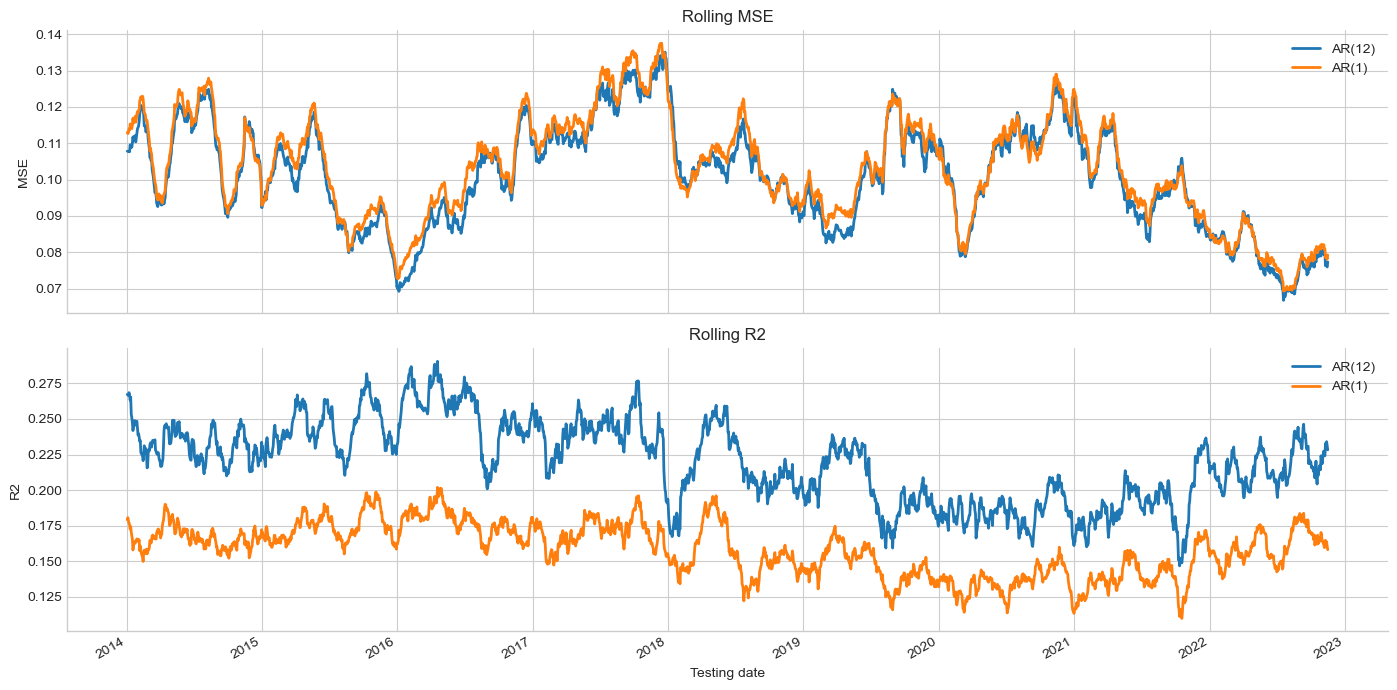

In [15]:
ROLLING_WINDOW = len(merged) // (6*12) # about one trading quarter

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for i, metric in enumerate(METRICS):
    ax = axes[i]

    model_roll = merged[f"{metric}_model"].rolling(ROLLING_WINDOW, min_periods=1).mean()
    baseline_roll = merged[f"{metric}_baseline"].rolling(ROLLING_WINDOW, min_periods=1).mean()
    testing_date_roll = merged["testing_date"]

    model_roll = model_roll[ROLLING_WINDOW:]
    baseline_roll = baseline_roll[ROLLING_WINDOW:]
    testing_date_roll = testing_date_roll[:-ROLLING_WINDOW]

    ax.plot(testing_date_roll, model_roll, label="AR(12)", linewidth=2)
    ax.plot(testing_date_roll, baseline_roll, label="AR(1)", linewidth=2)
    ax.set_ylabel(metric.upper())
    ax.set_title(f"Rolling {metric.upper()}")
    ax.legend(loc="best")

axes[-1].set_xlabel("Testing date")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


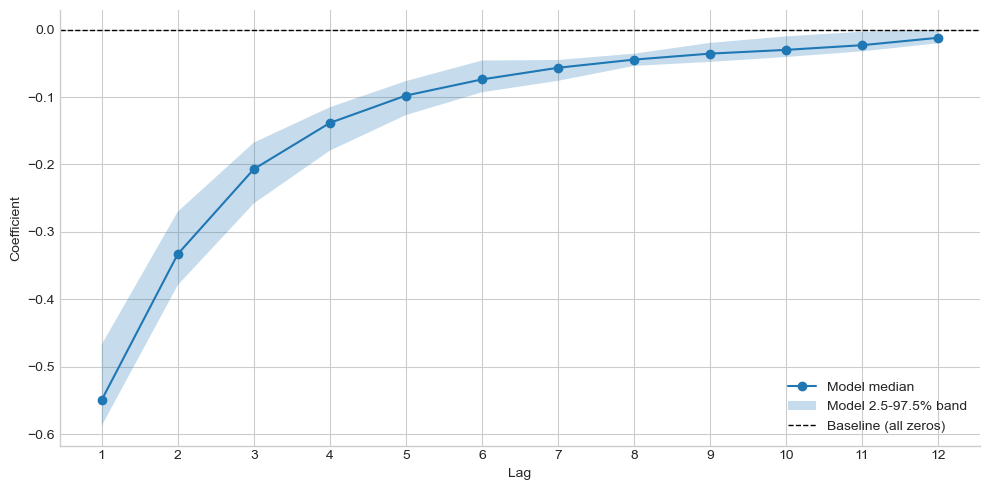

In [14]:
if HORIZON_COLS:
    model_horizon_cols = [f"{c}_model" for c in HORIZON_COLS][::-1]
    coeff = merged[model_horizon_cols].copy()
    coeff.columns = HORIZON_COLS

    q_low = coeff.quantile(0.025)
    q50 = coeff.quantile(0.50)
    q_large = coeff.quantile(0.975)

    horizons = np.arange(1, len(HORIZON_COLS) + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(horizons, q50.to_numpy(), marker="o", label="Model median")
    ax.fill_between(horizons, q_low.to_numpy(), q_large.to_numpy(), alpha=0.25, label="Model 2.5-97.5% band")
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1, label="Baseline (all zeros)")
    ax.set_xticks(horizons)
    ax.set_xlabel("Lag")
    ax.set_ylabel("Coefficient")
    # ax.set_title("Horizon coefficient profile (p_1..p_n)")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("No horizon coefficient columns found (expected p_1, p_2, ...).")


### Notes
- Positive gains indicate the model outperforms the baseline.
- For `mse` and `mae`, gains are percentage reductions relative to baseline.
- For `r2`, gain is the absolute difference (`model - baseline`).
